# LOSO Training — MultiBranch CNN

Leave-One-Subject-Out cross-validation for FOG detection.

**Before running:** fill in the `DEVICE_MAPPING` dictionary in cell 2 with the correct device → body part mapping for each subject.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

## 2. Configuration

###  Fill in DEVICE_MAPPING before running

For each subject, specify which device corresponds to `ankle_l`, `ankle_r`, and `back`.
Use `None` if a device was not functioning for that subject.

In [2]:
DATA_DIR = Path('/Users/zoemonnard/Library/CloudStorage/OneDrive-epfl.ch/fog_labeled_data/combined')

# ── FILL THIS IN ──────────────────────────────────────────────────
DEVICE_MAPPING = {
    'FOG002': {'ankle_l': 'dev5', 'ankle_r': 'dev2', 'back': 'dev3'},
    'FOG003': {'ankle_l': 'dev7', 'ankle_r': 'dev2', 'back': 'dev3'},
    'FOG004': {'ankle_l': 'dev7', 'ankle_r': 'dev2', 'back': 'dev3'},
    'FOG005': {'ankle_l': 'dev3', 'ankle_r': 'dev2', 'back': 'dev7'},
    'FOG006': {'ankle_l': 'dev5', 'ankle_r': 'dev2', 'back': 'dev6'},
    'FOG009': {'ankle_l': 'dev7', 'ankle_r': 'dev2', 'back': 'dev3'},
    'FOG010': {'ankle_l': 'dev5', 'ankle_r': 'dev6', 'back': 'dev3'},
    'FOG011': {'ankle_l': 'dev2', 'ankle_r': 'dev3', 'back': 'dev7'},
    'FOG012': {'ankle_l': 'dev3', 'ankle_r': 'dev4', 'back': 'dev7'},
    'FOG013': {'ankle_l': 'dev5', 'ankle_r': 'dev2', 'back': 'dev7'},
    'FOG014': {'ankle_l': 'dev4', 'ankle_r': 'dev3', 'back': 'dev5'},
    'FOG015': {'ankle_l': 'dev3', 'ankle_r': 'dev4', 'back': 'dev1'},
    'FOG016': {'ankle_l': 'dev4', 'ankle_r': 'dev7', 'back': 'dev3'},
    'FOG017': {'ankle_l': 'dev5', 'ankle_r': 'dev4', 'back': 'dev3'},
}
# ─────────────────────────────────────────────────────────────────

TEST_SUBJECTS = ['FOG002', 'FOG003', 'FOG004', 'FOG006', 'FOG010',
                 'FOG011', 'FOG012', 'FOG013', 'FOG014', 'FOG015']
ALL_SUBJECTS  = list(DEVICE_MAPPING.keys())

# Segmentation
FS       = 100    # Hz
W_SEC    = 2.0    # window size in seconds
OVERLAP  = 0.75   # 75% overlap — matches original training, maximizes FOG windows
WIN_SIZE = int(W_SEC * FS)
STEP     = int(WIN_SIZE * (1 - OVERLAP))

# Training — matches original training setup
BATCH_SIZE   = 256
N_EPOCHS     = 50
LR           = 5e-4   # matches original
WEIGHT_DECAY = 0.0036  # matches original
PATIENCE     = 10      # early stopping patience

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Window: {WIN_SIZE} samples ({W_SEC}s @ {FS}Hz) | Step: {STEP} samples')


Device: cpu
Window: 200 samples (2.0s @ 100Hz) | Step: 50 samples


## 3. Model architecture

In [3]:
# ── Model configuration ───────────────────────────────────────
# INPUT_MODE controls which channels are used:
#   'acc'      : acceleration only  — ankles: 6ch, back: 3ch (total 9)
#   'quat'     : quaternions only   — ankles: 8ch, back: 4ch (total 12)
#   'acc_quat' : both combined      — ankles: 14ch, back: 7ch (total 21)
INPUT_MODE = 'acc'  # ← change here

INPUT_CONFIG = {
    'acc'     : {'ankle_ch': 6,  'back_ch': 3},
    'quat'    : {'ankle_ch': 8,  'back_ch': 4},
    'acc_quat': {'ankle_ch': 14, 'back_ch': 7},
}

class MultiBranchCNN(nn.Module):
    def __init__(self, ankle_ch=6, back_ch=3):
        super().__init__()
        self.ankle_branch = nn.Sequential(
            nn.Conv1d(ankle_ch, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2), nn.Dropout(0.5),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.back_branch = nn.Sequential(
            nn.Conv1d(back_ch, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16), nn.ReLU(),
            nn.MaxPool1d(2), nn.Dropout(0.5),
            nn.Conv1d(16, 64, kernel_size=3, padding=1),
            nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.32),
            nn.Linear(64, 1)
            # No Sigmoid — BCEWithLogitsLoss applies it internally
        )

    def forward(self, x):
        ankle_ch = self.ankle_branch[0].in_channels
        ankles = x[:, :ankle_ch, :]
        back   = x[:, ankle_ch:, :]
        feat_ankles = self.ankle_branch(ankles).view(x.size(0), -1)
        feat_back   = self.back_branch(back).view(x.size(0), -1)
        return self.classifier(torch.cat([feat_ankles, feat_back], dim=1))

cfg = INPUT_CONFIG[INPUT_MODE]
print(f'Input mode  : {INPUT_MODE}')
print(f'Ankle ch    : {cfg["ankle_ch"]} | Back ch: {cfg["back_ch"]}')
print(f'Total input : {cfg["ankle_ch"] + cfg["back_ch"]} channels')


Input mode  : acc
Ankle ch    : 6 | Back ch: 3
Total input : 9 channels


## 4. Data loading helpers

In [4]:
QUAT_COLS = ['quat_w', 'quat_x', 'quat_y', 'quat_z']
ACC_COLS  = ['acc_x', 'acc_y', 'acc_z']

def get_feature_cols():
    """Return feature column names based on INPUT_MODE."""
    if INPUT_MODE == 'acc':
        return [
            'ankleL_ax', 'ankleL_ay', 'ankleL_az',
            'ankleR_ax', 'ankleR_ay', 'ankleR_az',
            'back_ax',   'back_ay',   'back_az',
        ]
    elif INPUT_MODE == 'quat':
        return [
            'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
            'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
            'back_q0',   'back_q1',   'back_q2',   'back_q3',
        ]
    else:  # acc_quat
        return [
            'ankleL_ax', 'ankleL_ay', 'ankleL_az',
            'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
            'ankleR_ax', 'ankleR_ay', 'ankleR_az',
            'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
            'back_ax',   'back_ay',   'back_az',
            'back_q0',   'back_q1',   'back_q2',   'back_q3',
        ]


def load_subject(subject_id):
    mapping = DEVICE_MAPPING[subject_id]
    if any(v is None for v in mapping.values()):
        print(f'  [{subject_id}] skipped — device mapping not filled in')
        return None
    dfs = {}
    for role, dev in mapping.items():
        path = DATA_DIR / f'IMU_{dev}_{subject_id}_all_tasks.csv'
        if not path.exists():
            print(f'  [{subject_id}] skipped — {path.name} not found')
            return None
        dfs[role] = pd.read_csv(path)
    min_len = min(len(df) for df in dfs.values())
    for role in dfs:
        dfs[role] = dfs[role].iloc[:min_len].reset_index(drop=True)

    # Build combined DataFrame with all channels
    combined = pd.DataFrame({
        # Ankle L
        'ankleL_ax': dfs['ankle_l']['acc_x'].values,
        'ankleL_ay': dfs['ankle_l']['acc_y'].values,
        'ankleL_az': dfs['ankle_l']['acc_z'].values,
        'ankleL_q0': dfs['ankle_l']['quat_w'].values,
        'ankleL_q1': dfs['ankle_l']['quat_x'].values,
        'ankleL_q2': dfs['ankle_l']['quat_y'].values,
        'ankleL_q3': dfs['ankle_l']['quat_z'].values,
        # Ankle R
        'ankleR_ax': dfs['ankle_r']['acc_x'].values,
        'ankleR_ay': dfs['ankle_r']['acc_y'].values,
        'ankleR_az': dfs['ankle_r']['acc_z'].values,
        'ankleR_q0': dfs['ankle_r']['quat_w'].values,
        'ankleR_q1': dfs['ankle_r']['quat_x'].values,
        'ankleR_q2': dfs['ankle_r']['quat_y'].values,
        'ankleR_q3': dfs['ankle_r']['quat_z'].values,
        # Back
        'back_ax'  : dfs['back']['acc_x'].values,
        'back_ay'  : dfs['back']['acc_y'].values,
        'back_az'  : dfs['back']['acc_z'].values,
        'back_q0'  : dfs['back']['quat_w'].values,
        'back_q1'  : dfs['back']['quat_x'].values,
        'back_q2'  : dfs['back']['quat_y'].values,
        'back_q3'  : dfs['back']['quat_z'].values,
        # Labels
        'fog'      : dfs['ankle_l']['fog_label'].values,
        'subject'  : subject_id,
    })

    # Drop NaN rows
    all_feat_cols = get_feature_cols()
    n_before  = len(combined)
    combined  = combined.dropna(subset=all_feat_cols).reset_index(drop=True)
    n_nan     = n_before - len(combined)
    if n_nan > 0:
        print(f'  [{subject_id}] dropped {n_nan} NaN rows ({100*n_nan/n_before:.2f}%)')
    return combined


def segment(df, win_size=WIN_SIZE, step=STEP):
    feat_cols = get_feature_cols()
    data   = df[feat_cols].values
    labels = df['fog'].values
    X, y = [], []
    for i in range(0, len(data) - win_size, step):
        window = data[i:i+win_size]
        if np.isnan(window).any():
            continue
        X.append(window - window[0])  # relative transform
        y.append(int(labels[i:i+win_size].max()))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


class FOGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.transpose(0, 2, 1))
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

FEATURE_COLS = get_feature_cols()
print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')


Feature columns (9): ['ankleL_ax', 'ankleL_ay', 'ankleL_az', 'ankleR_ax', 'ankleR_ay', 'ankleR_az', 'back_ax', 'back_ay', 'back_az']


## 4b. Data augmentation

In [5]:
# ── Experiment control ────────────────────────────────────────
# Change AUG_MULTIPLIER and EXPERIMENT_NAME between runs:
#   no_aug  : AUG_MULTIPLIER = 0   → baseline, no augmentation
#   aug_x5  : AUG_MULTIPLIER = 5   → ~6% FOG, light augmentation
#   aug_x23 : AUG_MULTIPLIER = 23  → ~19% FOG, heavy augmentation
AUG_MULTIPLIER  = 0        # ← change here
EXPERIMENT_NAME = 'no_aug' # ← change here: 'no_aug', 'aug_x5', 'aug_x23'

AUG_NOISE_STD   = 0.01
AUG_SCALE_RANGE = (0.9, 1.1)

def augment_noise(window):
    return window + np.random.normal(0, AUG_NOISE_STD, window.shape)

def augment_reverse(window):
    return window[::-1].copy()

def augment_scale(window):
    factor = np.random.uniform(*AUG_SCALE_RANGE)
    return window * factor

def augment_combined(window):
    window = augment_noise(window)
    if np.random.random() > 0.5:
        window = augment_reverse(window)
    if np.random.random() > 0.5:
        window = augment_scale(window)
    return window

AUGMENTATIONS = [augment_noise, augment_reverse, augment_scale, augment_combined]

def augment_fog_windows(X_train, y_train, multiplier=AUG_MULTIPLIER):
    """Augment only FOG windows. multiplier=0 disables augmentation."""
    if multiplier == 0:
        return X_train, y_train
    fog_idx = np.where(y_train == 1)[0]
    X_aug, y_aug = [], []
    for idx in fog_idx:
        window = X_train[idx]
        for _ in range(multiplier):
            aug_fn = AUGMENTATIONS[np.random.randint(len(AUGMENTATIONS))]
            X_aug.append(aug_fn(window).astype(np.float32))
            y_aug.append(1.0)
    if len(X_aug) == 0:
        return X_train, y_train
    X_aug = np.array(X_aug, dtype=np.float32)
    y_aug = np.array(y_aug, dtype=np.float32)
    X_out = np.concatenate([X_train, X_aug])
    y_out = np.concatenate([y_train, y_aug])
    idx   = np.random.permutation(len(X_out))
    return X_out[idx], y_out[idx]

print(f'Experiment  : {EXPERIMENT_NAME}')
print(f'Multiplier  : {AUG_MULTIPLIER}')
if AUG_MULTIPLIER > 0:
    approx_fog = (1.0 * (1 + AUG_MULTIPLIER)) / (100 + 1.0 * AUG_MULTIPLIER) * 100
    print(f'Expected FOG: ~{approx_fog:.1f}%')
else:
    print('Expected FOG: ~1% (no augmentation)')


Experiment  : no_aug
Multiplier  : 0
Expected FOG: ~1% (no augmentation)


## 5. LOSO cross-validation

In [6]:
# Pre-load all subjects
print('Loading subjects...')
subject_data = {}
for sub in ALL_SUBJECTS:
    df = load_subject(sub)
    if df is not None:
        subject_data[sub] = df
        print(f'  {sub}: {len(df):>8} samples | FOG: {df["fog"].mean()*100:.2f}%')

available_subjects = list(subject_data.keys())
test_subjects = [s for s in TEST_SUBJECTS if s in available_subjects]
print(f'\nAvailable: {len(available_subjects)} subjects')
print(f'Test folds: {len(test_subjects)}')

Loading subjects...
  FOG002:   347625 samples | FOG: 0.38%
  [FOG003] dropped 3 NaN rows (0.00%)
  FOG003:   463029 samples | FOG: 2.20%
  FOG004:   209980 samples | FOG: 0.06%
  FOG005:   192775 samples | FOG: 0.00%
  FOG006:   334975 samples | FOG: 0.21%
  FOG009:   217126 samples | FOG: 0.00%
  FOG010:   234090 samples | FOG: 0.10%
  FOG011:   271405 samples | FOG: 0.17%
  FOG012:   189237 samples | FOG: 0.90%
  FOG013:   395528 samples | FOG: 1.29%
  FOG014:   362495 samples | FOG: 0.03%
  FOG015:   270137 samples | FOG: 0.66%
  FOG016:   289230 samples | FOG: 0.00%
  FOG017:   234655 samples | FOG: 0.00%

Available: 14 subjects
Test folds: 10


In [ ]:
loso_results = []

for fold_idx, test_sub in enumerate(test_subjects):
    print(f'\n━━━ Fold {fold_idx+1}/{len(test_subjects)} — Test: {test_sub} ━━━')

    # ── Split ──────────────────────────────────────────────────────
    train_subs = [s for s in available_subjects if s != test_sub]
    X_train_list, y_train_list = [], []
    for sub in train_subs:
        X, y = segment(subject_data[sub])
        X_train_list.append(X)
        y_train_list.append(y)
    X_train = np.concatenate(X_train_list)
    y_train = np.concatenate(y_train_list)
    X_test, y_test = segment(subject_data[test_sub])

    print(f'Train: {len(X_train)} windows | FOG: {y_train.sum():.0f} ({100*y_train.mean():.1f}%)')
    print(f'Test : {len(X_test)}  windows | FOG: {y_test.sum():.0f} ({100*y_test.mean():.1f}%)')

    # ── Data augmentation ──────────────────────────────────────────
    n_fog_before = int(y_train.sum())
    X_train, y_train = augment_fog_windows(X_train, y_train)
    print(f'After augmentation: {len(X_train)} windows | '
          f'FOG: {int(y_train.sum())} ({100*y_train.mean():.1f}%) '
          f'[was {n_fog_before} FOG windows]')

    # ── Class weight ───────────────────────────────────────────────
    n_fog     = y_train.sum()
    n_non_fog = len(y_train) - n_fog
    pos_weight = torch.tensor([n_non_fog / max(n_fog, 1)]).to(DEVICE)
    print(f'pos_weight: {pos_weight.item():.1f}')

    # ── Dataloaders ────────────────────────────────────────────────
    train_loader = DataLoader(FOGDataset(X_train, y_train),
                              batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(FOGDataset(X_test, y_test),
                              batch_size=BATCH_SIZE, shuffle=False)

    # ── Model ──────────────────────────────────────────────────────
    cfg   = INPUT_CONFIG[INPUT_MODE]
    model = MultiBranchCNN(ankle_ch=cfg['ankle_ch'], back_ch=cfg['back_ch']).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', patience=20, factor=0.5, verbose=False
    )

    # ── Training loop — AUC-based model selection ──────────────────
    best_auc    = 0
    best_state  = {k: v.clone() for k, v in model.state_dict().items()}
    patience_counter = 0

    for epoch in range(N_EPOCHS):
        # Train
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validate
        model.eval()
        probs, targets = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                logits = model(X_batch.to(DEVICE)).squeeze().cpu()
                probs.extend(torch.sigmoid(logits).numpy())
                targets.extend(y_batch.numpy())
        probs, targets = np.array(probs), np.array(targets)
        preds = (probs >= 0.5).astype(int)
        f1  = f1_score(targets, preds, zero_division=0)
        rec = recall_score(targets, preds, zero_division=0)

        # AUC-based model selection
        try:
            auc = roc_auc_score(targets, probs) if targets.sum() > 0 else 0
        except:
            auc = 0
        scheduler.step(1 - auc)

        if auc > best_auc:
            best_auc         = auc
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'  Early stopping at epoch {epoch+1}')
                break

        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:02d}/{N_EPOCHS} | '
                  f'loss: {train_loss/len(train_loader):.4f} | '
                  f'F1: {f1:.3f} | Recall: {rec:.3f} | '
                  f'AUC: {auc:.3f} | patience: {patience_counter}/{PATIENCE}')

    # ── Final evaluation ───────────────────────────────────────────
    model.load_state_dict(best_state)
    model.eval()
    probs, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model(X_batch.to(DEVICE)).squeeze().cpu()
            probs.extend(torch.sigmoid(logits).numpy())
            targets.extend(y_batch.numpy())
    probs, targets = np.array(probs), np.array(targets)
    preds = (probs >= 0.5).astype(int)
    precision = precision_score(targets, preds, zero_division=0)
    recall    = recall_score(targets, preds, zero_division=0)
    f1        = f1_score(targets, preds, zero_division=0)
    try:
        auc = roc_auc_score(targets, probs)
    except:
        auc = float('nan')

    # Find best threshold from ROC curve
    try:
        from sklearn.metrics import roc_curve
        fpr, tpr, thresholds = roc_curve(targets, probs)
        best_thresh = thresholds[np.argmax(tpr - fpr)]
        preds_best  = (probs >= best_thresh).astype(int)
        f1_best     = f1_score(targets, preds_best, zero_division=0)
        rec_best    = recall_score(targets, preds_best, zero_division=0)
        prec_best   = precision_score(targets, preds_best, zero_division=0)
        print(f'  Best threshold: {best_thresh:.3f} → '
              f'Precision: {prec_best:.3f} | Recall: {rec_best:.3f} | F1: {f1_best:.3f}')
    except:
        best_thresh = 0.5
        f1_best     = f1

    print(f'\n  ✓ @ 0.5 — Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}')
    torch.save(model.state_dict(), f'model_LOSO_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.pth')
    loso_results.append({
        'test_subject'  : test_sub,
        'precision'     : precision,
        'recall'        : recall,
        'f1'            : f1,
        'f1_best_thresh': f1_best,
        'best_threshold': best_thresh,
        'auc'           : auc,
        'n_test_windows': len(targets),
        'fog_windows'   : int(targets.sum())
    })

print('\n━━━ LOSO complete ━━━')



━━━ Fold 1/10 — Test: FOG002 ━━━
Train: 73247 windows | FOG: 1304 (1.8%)
Test : 6949  windows | FOG: 66 (0.9%)
After augmentation: 73247 windows | FOG: 1304 (1.8%) [was 1304 FOG windows]
pos_weight: 55.2


[W NNPACK.cpp:61] Could not initialize NNPACK! Reason: Unsupported hardware.


## 6. Results summary

In [9]:
df_results = pd.DataFrame(loso_results)

print('=== LOSO Results per subject ===')
print(df_results[['test_subject', 'precision', 'recall', 'f1', 'auc']].to_string(index=False))

print('\n=== Mean ± Std across folds ===')
for col in ['precision', 'recall', 'f1', 'auc']:
    print(f'  {col:12s}: {df_results[col].mean():.3f} ± {df_results[col].std():.3f}')

df_results.to_csv(f'loso_results_{INPUT_MODE}_{EXPERIMENT_NAME}.csv', index=False)
print('\nResults saved: loso_results.csv')

=== LOSO Results per subject ===
test_subject  precision   recall       f1      auc
      FOG002   0.014264 0.897196 0.028082 0.777577
      FOG003   0.080548 0.705390 0.144585 0.658616
      FOG004   0.013245 0.625000 0.025940 0.811090
      FOG006   0.013638 0.852459 0.026846 0.845358
      FOG010   0.005492 0.407407 0.010837 0.656734
      FOG011   0.009408 0.563636 0.018507 0.671419
      FOG012   0.009448 0.072626 0.016720 0.447151
      FOG013   0.068238 0.922438 0.127075 0.868410
      FOG014   0.002940 0.545455 0.005848 0.891832
      FOG015   0.063566 0.706897 0.116643 0.844599

=== Mean ± Std across folds ===
  precision   : 0.028 ± 0.030
  recall      : 0.630 ± 0.256
  f1          : 0.052 ± 0.054
  auc         : 0.747 ± 0.138

Results saved: loso_results.csv


## 7. Results plot

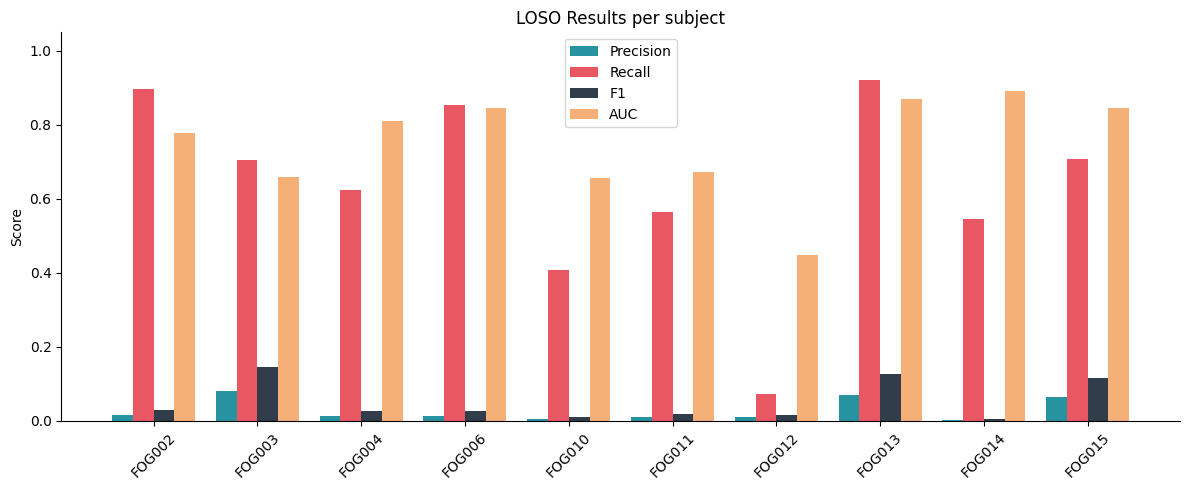

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_results))
w = 0.2

for i, (col, color, label) in enumerate([
    ('precision', '#028090', 'Precision'),
    ('recall',    '#E63946', 'Recall'),
    ('f1',        '#0D1B2A', 'F1'),
    ('auc',       '#F4A261', 'AUC'),
]):
    ax.bar(x + i*w, df_results[col], w, label=label, color=color, alpha=0.85)

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(df_results['test_subject'], rotation=45)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('LOSO Results per subject')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('loso_results.png', dpi=150)
plt.show()

In [11]:
# Run inference only using saved models (no retraining needed)
for test_sub in test_subjects:
    # Load data
    X_test, y_test = segment(subject_data[test_sub])
    test_loader = DataLoader(FOGDataset(X_test, y_test), batch_size=256, shuffle=False)

    # Load saved model
    cfg   = INPUT_CONFIG[INPUT_MODE]
    model = MultiBranchCNN(ankle_ch=cfg['ankle_ch'], back_ch=cfg['back_ch']).to(DEVICE)
    model.load_state_dict(torch.load(f'model_LOSO_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.pth',
                                      map_location=DEVICE))
    model.eval()

    # Inference
    probs, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model(X_batch.to(DEVICE)).squeeze().cpu()
            probs.extend(torch.sigmoid(logits).numpy())
            targets.extend(y_batch.numpy())

    probs   = np.array(probs)
    targets = np.array(targets)

    # Save
    np.save(f'probs_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy', probs)
    np.save(f'targets_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy', targets)
    print(f'{test_sub} done — {len(probs)} windows')

FOG002 done — 13901 windows
FOG003 done — 18518 windows
FOG004 done — 8396 windows
FOG006 done — 13395 windows
FOG010 done — 9360 windows
FOG011 done — 10853 windows
FOG012 done — 7566 windows
FOG013 done — 15818 windows
FOG014 done — 14496 windows
FOG015 done — 10802 windows


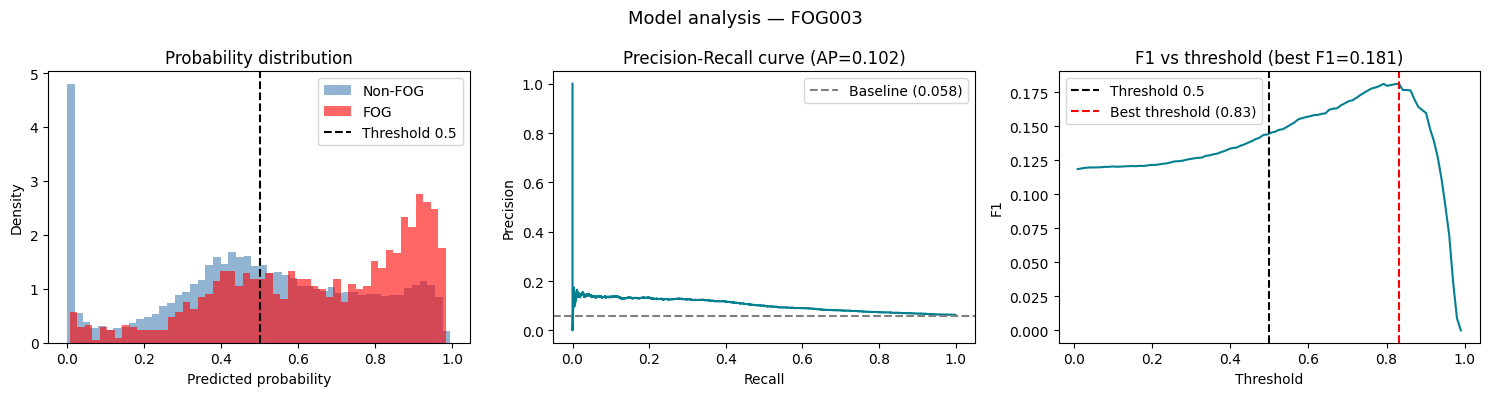

In [12]:
# Pick the most informative fold (most FOG in test)
sub = 'FOG003'
probs   = np.load(f'probs_{sub}_acc_no_aug.npy')
targets = np.load(f'targets_{sub}_acc_no_aug.npy')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Probability distribution FOG vs non-FOG
ax = axes[0]
ax.hist(probs[targets==0], bins=50, alpha=0.6, color='steelblue', label='Non-FOG', density=True)
ax.hist(probs[targets==1], bins=50, alpha=0.6, color='red',       label='FOG',     density=True)
ax.axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Density')
ax.set_title('Probability distribution')
ax.legend()

# Plot 2 — Precision-Recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, thresholds = precision_recall_curve(targets, probs)
ap = average_precision_score(targets, probs)
ax = axes[1]
ax.plot(recall, precision, color='#028090')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall curve (AP={ap:.3f})')
ax.axhline(targets.mean(), color='gray', linestyle='--', label=f'Baseline ({targets.mean():.3f})')
ax.legend()

# Plot 3 — F1 at different thresholds
from sklearn.metrics import f1_score
thresh_range = np.linspace(0.01, 0.99, 100)
f1_scores = [f1_score(targets, (probs>=t).astype(int), zero_division=0) for t in thresh_range]
ax = axes[2]
ax.plot(thresh_range, f1_scores, color='#028090')
ax.axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
ax.axvline(thresh_range[np.argmax(f1_scores)], color='red', linestyle='--',
           label=f'Best threshold ({thresh_range[np.argmax(f1_scores)]:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1')
ax.set_title(f'F1 vs threshold (best F1={max(f1_scores):.3f})')
ax.legend()

plt.suptitle(f'Model analysis — {sub}', fontsize=13)
plt.tight_layout()
plt.savefig(f'model_analysis_{sub}.png', dpi=150)
plt.show()

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score
from torch.utils.data import DataLoader

# For each subject, reload data keeping task_name, run inference, then analyze by task
task_results = []

for test_sub in test_subjects:
    # Load raw combined df (with task_name column)
    mapping = DEVICE_MAPPING[test_sub]
    df = load_subject(test_sub)  # already loaded in subject_data but without task_name
    
    # Reload with task_name — use ankle_l device as reference
    dev = mapping['ankle_l']
    df_raw = pd.read_csv(DATA_DIR / f'IMU_{dev}_{test_sub}_all_tasks.csv')
    
    # Load saved probs and targets
    probs   = np.load(f'probs_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy')
    targets = np.load(f'targets_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy')
    
    # Rebuild window-level task labels (same segmentation as training)
    feat_cols = get_feature_cols()
    df_combined = subject_data[test_sub]
    
    # Get task name per window
    task_labels_raw = df_combined['task_name'].values if 'task_name' in df_combined.columns else None
    
    if task_labels_raw is None:
        # Re-add task_name from the raw file
        ankle_l_df = pd.read_csv(DATA_DIR / f'IMU_{mapping["ankle_l"]}_{test_sub}_all_tasks.csv')
        min_len = len(subject_data[test_sub])
        task_labels_raw = ankle_l_df['task_name'].values[:min_len]
    
    # Segment task names with same window/step
    window_tasks = []
    for i in range(0, len(task_labels_raw) - WIN_SIZE, STEP):
        window_task = pd.Series(task_labels_raw[i:i+WIN_SIZE]).mode()[0]
        window_tasks.append(window_task)
    window_tasks = np.array(window_tasks[:len(probs)])
    
    # Analyze per task
    for task in np.unique(window_tasks):
        mask = window_tasks == task
        if mask.sum() < 10 or targets[mask].sum() == 0:
            continue  # skip tasks with too few windows or no FOG
        try:
            auc  = roc_auc_score(targets[mask], probs[mask])
            preds = (probs[mask] >= 0.5).astype(int)
            f1   = f1_score(targets[mask], preds, zero_division=0)
            fog_pct = 100 * targets[mask].mean()
            task_results.append({
                'subject': test_sub,
                'task':    task,
                'n_windows': int(mask.sum()),
                'fog_pct':   round(fog_pct, 2),
                'auc':       round(auc, 3),
                'f1':        round(f1, 3),
            })
        except:
            pass

df_task = pd.DataFrame(task_results)
print(df_task.to_string(index=False))

  [FOG003] dropped 3 NaN rows (0.00%)
subject              task  n_windows  fog_pct   auc    f1
 FOG002 8_Shape_Circuit_1       4260     1.71 0.695 0.048
 FOG002 Narrow_Corridor_1       3977     0.85 0.772 0.034
 FOG003 8_Shape_Circuit_1       5806     9.66 0.623 0.208
 FOG003 Narrow_Corridor_1       5688     7.07 0.686 0.182
 FOG003       Obstacles_1       3006     0.96 0.525 0.018
 FOG003       Obstacles_2       2731     2.82 0.613 0.067
 FOG003       Stop_Task_1       1287     0.54 0.630 0.019
 FOG004 Narrow_Corridor_1       4175     0.38 0.800 0.045
 FOG006 8_Shape_Circuit_1       4680     1.03 0.804 0.050
 FOG006 Narrow_Corridor_1       4483     0.29 0.906 0.020
 FOG010 8_Shape_Circuit_1       3839     0.70 0.677 0.027
 FOG011       Obstacles_1       2037     2.70 0.557 0.065
 FOG012 8_Shape_Circuit_1       2877     0.70 0.511 0.011
 FOG012 Narrow_Corridor_1       2076     7.66 0.402 0.030
 FOG013 8_Shape_Circuit_1       4929     2.25 0.918 0.178
 FOG013 Narrow_Corridor_1       37

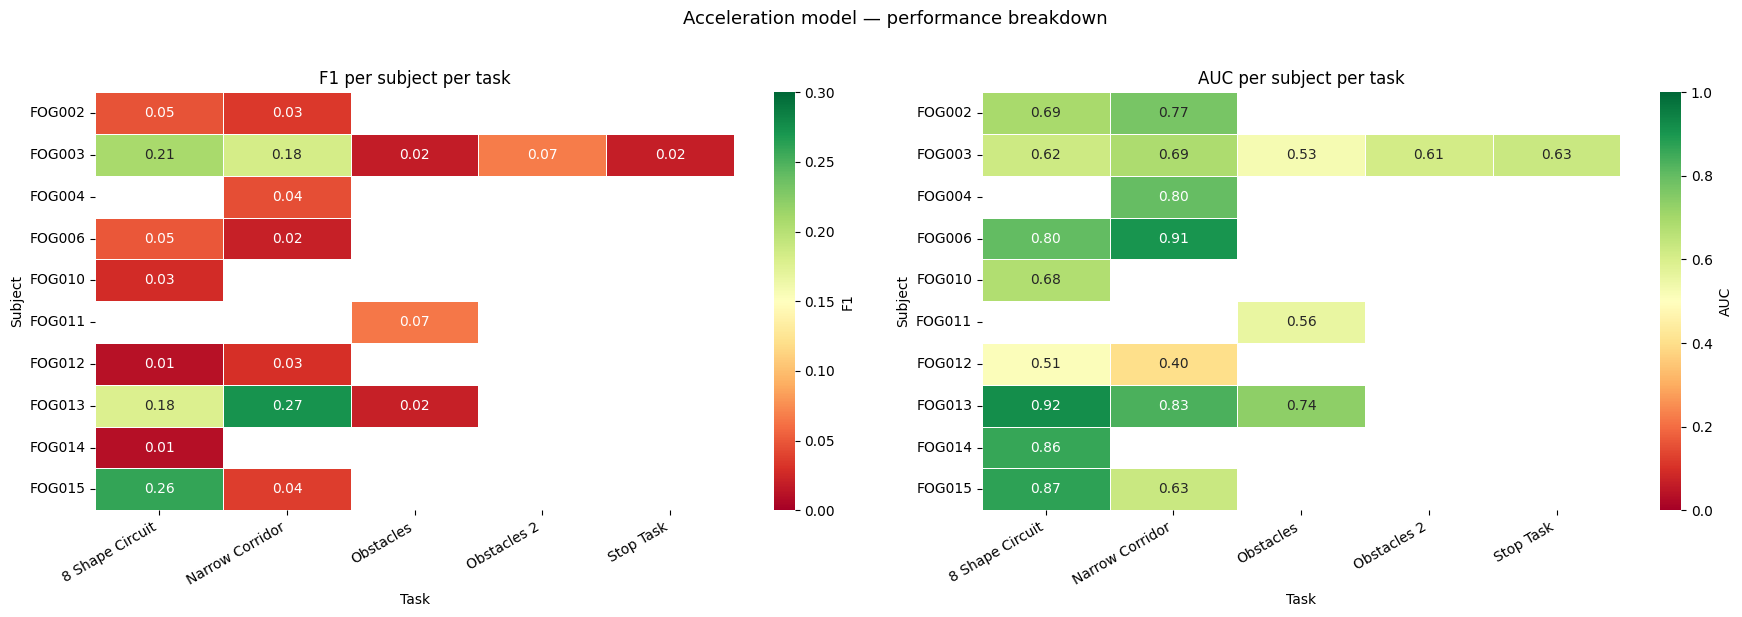

In [16]:
df_pivot_auc = df_task.pivot_table(
    index='subject', columns='task', values='auc', aggfunc='mean'
)
df_pivot_auc.columns = [c.replace('_1', '').replace('_', ' ') for c in df_pivot_auc.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (df_piv, metric, vmax, title) in zip(axes, [
    (df_pivot_f1,  'F1',  0.3,  'F1 per subject per task'),
    (df_pivot_auc, 'AUC', 1.0,  'AUC per subject per task'),
]):
    sns.heatmap(
        df_piv,
        annot=True, fmt='.2f',
        cmap='RdYlGn',
        vmin=0, vmax=vmax,
        linewidths=0.5, linecolor='white',
        ax=ax,
        mask=df_piv.isna(),
        cbar_kws={'label': metric}
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Task')
    ax.set_ylabel('Subject')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Acceleration model — performance breakdown', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('heatmap_f1_auc_subject_task.png', dpi=150)
plt.show()

In [26]:
INPUT_MODE = 'acc'  # ← change here
EXPERIMENT_NAME = 'no_aug' # ← change here: 'no_aug', 'aug_x5', 'aug_x23'

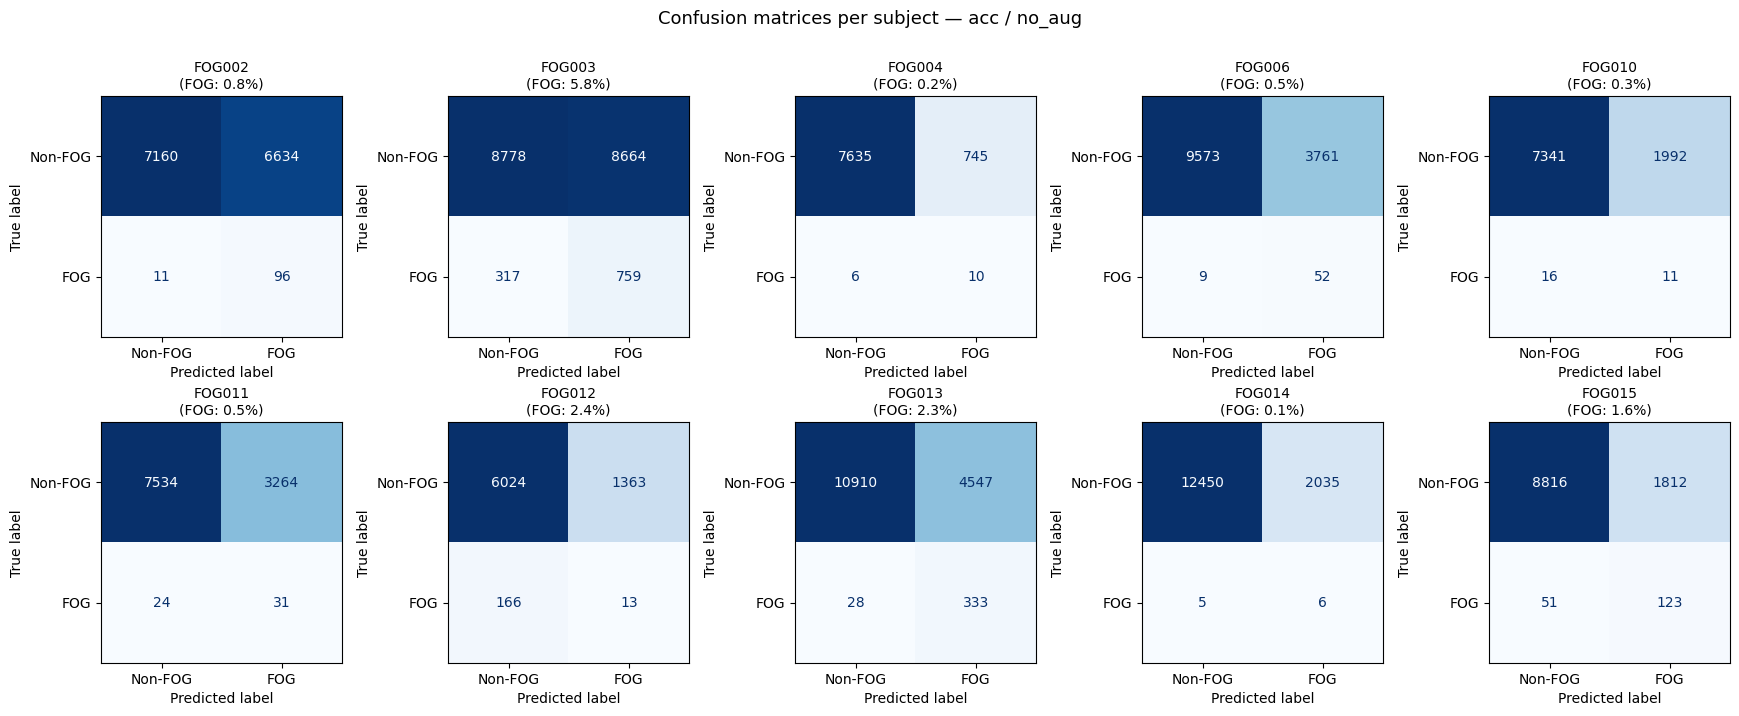

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

n_subs = len(test_subjects)
ncols = 5
nrows = (n_subs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
axes = axes.flatten()

for i, test_sub in enumerate(test_subjects):
    probs   = np.load(f'probs_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy')
    targets = np.load(f'targets_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy').astype(int)
    preds   = (probs >= 0.5).astype(int)

    cm = confusion_matrix(targets, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-FOG', 'FOG'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')

    fog_pct = 100 * targets.mean()
    axes[i].set_title(f'{test_sub}\n(FOG: {fog_pct:.1f}%)', fontsize=10)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Confusion matrices per subject — {INPUT_MODE} / {EXPERIMENT_NAME}',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'confusion_matrices_{INPUT_MODE}_{EXPERIMENT_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()
